In [ ]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats


In [4]:
df = pd.read_csv("data/EDA.csv")

df.head()

,WD EID,Emp Name,Answered,AHT,Month,Year,Dayofweek,Monthly_AHT,Dayofweek_AHT,Monthly_Answered,Dayofweek_Answered,Shift
0,102496670,Dieu Tien,60.0,452.0,5,2026,6,452.818182,473.666667,60.181818,57.666667,Day
1,102496670,Dieu Tien,60.0,451.0,5,2026,0,452.818182,476.500000,60.181818,57.500000,Day
2,102496670,Dieu Tien,70.0,414.0,5,2026,1,452.818182,411.500000,60.181818,67.500000,Day
3,102496670,Dieu Tien,70.0,406.0,5,2026,4,452.818182,451.000000,60.181818,63.500000,Day
4,102496670,Dieu Tien,55.0,412.0,5,2026,5,452.818182,441.000000,60.181818,56.000000,Day


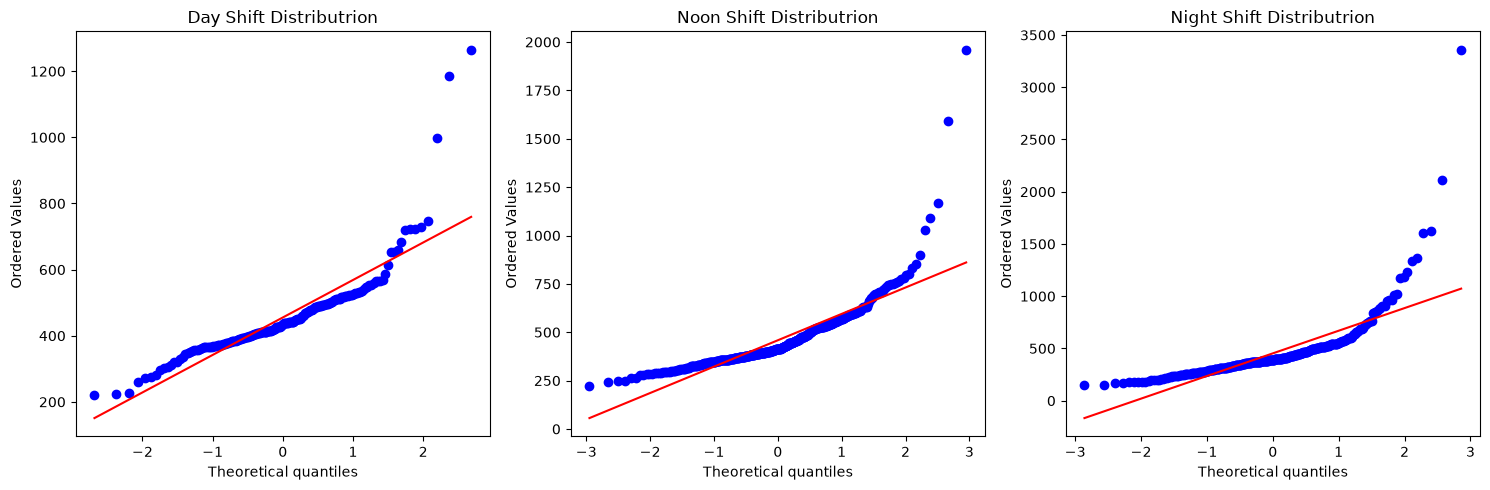

In [6]:
#QQ plot distributed by shift
day_shift = df.loc[df.Shift == "Day", ["AHT"]]
noon_shift = df.loc[df.Shift == "Noon", ["AHT"]]
night_shift = df.loc[df.Shift == "Night", ["AHT"]]

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

stats.probplot(day_shift["AHT"], dist="norm", plot=ax[0])
ax[0].set_title("Day Shift Distributrion")

stats.probplot(noon_shift["AHT"], dist="norm", plot=ax[1])
ax[1].set_title("Noon Shift Distributrion")

stats.probplot(night_shift["AHT"], dist="norm", plot=ax[2])
ax[2].set_title("Night Shift Distributrion")

plt.tight_layout()
plt.show()

In [61]:
shift = ["Day", "Noon", "Night"]
shift_mean = []
shift_median = []
shift_mode = []
for i in shift:
    result = df.loc[df.Shift == i, "AHT"].mean()
    shift_mean.append(result)

    result = df.loc[df.Shift == i, "AHT"].median()
    shift_median.append(result)

    result = df.loc[df.Shift == i, "AHT"].mode()[0]
    shift_mode.append(result)

stat = pd.DataFrame({"Shift": shift, "Mean":np.array(shift_mean), "Median": np.array(shift_median), "Mode":np.array(shift_mode)})

stat["distribution"] = np.where(
    (stat.Mean == stat.Median) | (stat.Mean == stat.Mode), "Zero Skew", 
    np.where(stat.Mean > stat.Median, "Right-Tailed", "Left-Tailed")
    )

stat

,Shift,Mean,Median,Mode,distribution
0,Day,455.300000,434.5,358.0,Right-Tailed
1,Noon,458.548165,412.5,358.0,Right-Tailed
2,Night,453.131902,391.0,341.0,Right-Tailed


Heavy right-tailed 
Positive skewed distribution

               Is Mean equal to Median and Mode?
                         /           \
                       Yes            No
                       /               \
            [Symmetrical]               Is Mean greater than Median?
            (Zero Skew)                           /           \
                                                Yes            No
                                                /               \
                                    [Positively Skewed]     [Negatively Skewed]
                                       (Right-Tailed)          (Left-Tailed)


# Shapiro Testing

- Null Hypothesis (H₀): The data is normally distributed. (p_value >= 0.05)
- Alternative Hypothesis (H₁): The data is not normally distributed. (p_value < 0.05)

In [57]:
num = df["WD EID"].nunique()

print(f"Actual total emmployee: {num}")

Actual total emmployee: 25


In [58]:
shift_n = (
    df.groupby("Shift")
      .agg(
          n_observations=("AHT", "count"),
          n_employees=("WD EID", "nunique")
      )
      .reset_index()
)

shift_n

,Shift,n_observations,n_employees
0,Day,190,10
1,Night,326,13
2,Noon,436,19


In [59]:
for i in shift:
    stat, p_value = stats.shapiro(df.loc[df.Shift == i, "AHT"])
    print(i)
    print(f"Test Statistic: {stat:.4f}")
    print(f"P-value: {p_value:.4f}")



Day
Test Statistic: 0.7766
P-value: 0.0000
Noon
Test Statistic: 0.7477
P-value: 0.0000
Night
Test Statistic: 0.6067
P-value: 0.0000


# Levene Testing
- Null Hypothesis (H₀): The variances across all groups are equal. (p_value >= 0.05)
- Alternative Hypothesis (H₁): At least one group has a significantly different variance. (p_value < 0.05)

In [60]:
stat_l, p_value_l = stats.levene(day_shift, noon_shift, night_shift)

pd.DataFrame({"Levene":["Test Statistics", "P_value"], "Output": [stat_l, p_value_l]})



,Levene,Output
0,Test Statistics,[9.013338663928835]
1,P_value,[0.00013251677112250965]


# Statistics Assumption Conclusion:

> The **Shapiro–Wilk** tests indicate significant departures from normality across all three shifts, while **Levene's** test indicates unequal variances. Besides that, according to skewness of each specified shift, the distribution tail is heavy right-skewed showing a strong evidence of unbalanced dataset. More importantly, observations are repeatedly collected from the same employees across different months and shifts, violating the independence assumption of conventional between-group tests. These characteristics make a **Linear Mixed Effects Model** a more appropriate candidate for the final analysis.